In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data, regions, popls

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
# regions = sorted(df['region'].unique())
# popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

In [2]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report

ordinal_encoder = OrdinalEncoder()
Xcat = ordinal_encoder.fit_transform(df[genes].values.astype('<U2'))

one_hot_encoder = OneHotEncoder(sparse=False)
Xoh = one_hot_encoder.fit_transform(df[genes].values.astype('<U2'))
grps_xoh = df[genes].nunique().values

Xnum = df_chs.loc[:, df_chs.nunique(dropna=False) > 1].values
grps_xnum = np.sum( (df_chs.nunique(dropna=False) > 1).values.reshape(-1, 4) , axis=-1)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])

def cv_splitter(X, y, strat, n_splits, shuffle=True, random_state=None):
    for train_idxs, test_idxs in StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state).split(X, strat):
        yield X[train_idxs], X[test_idxs], y[train_idxs], y[test_idxs]

def group_sum(arr, grp_sizes):
    assert arr.shape[-1] == np.sum(grp_sizes)
    result = []
    lb = 0
    for grp_size in grp_sizes:
        result.append( np.sum(arr[..., lb:lb+grp_size], axis=-1) )
        lb += grp_size
    result = np.stack(result, axis=-1)
    return result

In [3]:
from sklearn.inspection import permutation_importance


## Distance-irrelevant classifiers: CategoricalNB, Categorical RF, Catboost

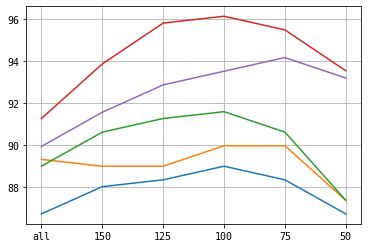

In [27]:
from sklearn.naive_bayes import CategoricalNB

models_cat_nb = []
fi_cat_nb_var = []
# fi_cat_nb_perm = []
# print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xcat, y, df['popl'], n_splits=5, random_state=42):
    min_categories = np.max(Xcat, axis=0).astype(int)+1
    model = CategoricalNB(
        alpha=1.,
        min_categories=min_categories
        )
    model.fit(X_train, y_train)
    models_cat_nb.append(model)
    
    # fi = np.array([np.sum(np.var(np.exp( log_prob ), axis=0)) for log_prob in model.feature_log_prob_])
    fi = permutation_importance(model, X_test, y_test, scoring='neg_log_loss', n_repeats=30, random_state=42)['importances_mean']
    fi_cat_nb_var.append( fi )

    val_score = [(100*np.mean(model.predict(X_test) == y_test))]
    for n_vars in (150, 125, 100, 75, 50):
        choice = np.argsort(fi)[-n_vars:]
        model = CategoricalNB(
            alpha=1.,
            min_categories=min_categories[choice]
            )
        model.fit(X_train[:, choice], y_train)
        val_score.append( 100*accuracy_score(y_test, model.predict(X_test[:, choice])) )
    plt.plot(val_score)
    plt.xticks(np.arange(len(val_score)), labels=('all', ) + (150, 125, 100, 75, 50))
plt.grid(); plt.show(); plt.close()
    # fi_cat_nb_perm.append( permutation_importance(model, X_test, y_test, scoring='neg_log_loss', n_repeats=30, random_state=42)['importances_mean'] )

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 568,
    'criterion': 'entropy',
    'max_depth': 14,
    'min_samples_split': 0.003294411356704213,
    'min_samples_leaf': 0.0010234416524205442,
}

models_cat_rf = []
fi_cat_rf_in = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xoh, y, df['popl'], n_splits=5, random_state=42):
    model = RandomForestClassifier(
        **rf_params,
        random_state=42
    )
    model.fit(X_train, y_train)
    models_cat_rf.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )
    fi_cat_rf_in.append( group_sum(model.feature_importances_, grps_xoh) )

train	test
100.00%	84.47%
100.00%	88.67%
100.00%	86.73%
99.92%	89.64%
99.92%	86.69%


In [6]:
from catboost import CatBoostClassifier, EFstrType, Pool

catboost_params = {
    'iterations': 1690,
    'learning_rate': 0.07455163375490914,
    'depth': 5,
    'l2_leaf_reg': 0.2593960559993001
}

models_catboost = []
fi_catboost_loss = []
fi_catboost_val = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(df[genes].values.astype('<U2'), y, df['popl'], n_splits=5, random_state=42):
    model = CatBoostClassifier(random_state=42)
    model.fit(
        Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes),
        verbose=0
    )
    models_catboost.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train).ravel() == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test).ravel() == y_test)), sep=''
    )
    fi_catboost_loss.append(
        model.get_feature_importance(
            Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes), 
            type=EFstrType.LossFunctionChange
        )
    )
    fi_catboost_val.append(
        model.get_feature_importance(
            Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes), 
            type=EFstrType.PredictionValuesChange
        )
    )

train	test
97.81%	87.38%
97.98%	86.73%
97.81%	89.00%
98.14%	89.64%
97.82%	89.61%


## LR, SVM, KNN, MultinomialNB

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics.pairwise import distance_metrics

def nan_l1_dist(X, Y, missing_values=np.nan):
    # if Y is None:
    #     Y = X
    # assert np.isnan(missing_values)

    diff = X - Y
    na_count = np.sum(np.isnan(diff))
    distance = np.nansum(np.abs(diff))
    distance *= (X.shape[-1] / (X.shape[-1]-na_count))
    return distance

    # X_fill = np.nan_to_num(X)
    # Y_fill = np.nan_to_num(Y)
    # distances = distance_metrics()['manhattan'](X_fill, Y_fill)
    # distances -= np.dot(np.abs(X_fill), np.isnan(Y).T)
    # distances -= np.dot(np.isnan(X), np.abs(Y_fill).T)
    
    # notna_count = np.dot(~np.isnan(X), ~np.isnan(Y).T)
    # distances[notna_count == 0] = np.nan
    # distances /= np.maximum(1, notna_count)
    # distances *= X.shape[-1]

    # return distances    

In [8]:
from sklearn.linear_model import LogisticRegression

lr_params = {
    'knnimputer__n_neighbors': 45,
    'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}

models_lr = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        LogisticRegression(
            penalty='l2',
            C=1., 
            solver='saga', 
            max_iter=1000,
            random_state=42
        )
    )
    model.set_params(**lr_params)
    model.fit(X_train, y_train)
    models_lr.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
90.93%	88.35%
91.66%	86.73%
91.42%	87.38%
90.93%	89.32%
91.50%	87.66%


In [9]:
from sklearn.svm import SVC

svc_params = {
    'knnimputer__n_neighbors': 12,
    'knnimputer__metric': 'nan_euclidean',
    'svc__C': 0.3289812567312727,
    'svc__kernel': 'poly',
    'svc__degree': 8,
    'svc__gamma': 'auto'
}
models_svc = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        SVC(
            C=1., 
            kernel='rbf',
            degree=3,
            gamma='scale',
            coef0=0.0,
            random_state=42
        )
    )
    model.set_params(**svc_params)
    model.fit(X_train, y_train)
    models_svc.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
98.14%	90.29%
98.30%	87.70%
98.54%	88.67%
98.30%	92.56%
98.22%	88.31%


In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_params= {
    'knnimputer__n_neighbors': 6,
    'knnimputer__metric': 'nan_euclidean',
    'kneighborsclassifier__n_neighbors': 15,
    'kneighborsclassifier__weights': 'distance',
    'kneighborsclassifier__metric': 'euclidean'
}
models_knn = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        KNeighborsClassifier(
            n_neighbors=25, 
            weights='uniform',
            metric='manhattan'
        )
    )
    model.set_params(**knn_params)
    model.fit(X_train, y_train)
    models_knn.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
100.00%	82.20%
100.00%	84.79%
100.00%	82.52%
100.00%	81.88%
100.00%	84.74%


In [11]:
from sklearn.naive_bayes import MultinomialNB

models_mn_nb = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MultinomialNB(
            alpha=1.
        )
    )
    model.fit(X_train, y_train)
    models_mn_nb.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
90.93%	86.41%
90.69%	88.03%
90.69%	89.64%
89.31%	92.23%
90.21%	90.26%


## What about DNN?

In [12]:
from sklearn.neural_network import MLPClassifier

models_mlp = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MLPClassifier(
            hidden_layer_sizes=(128, 32, ),
            alpha=1e-2,
            max_iter=2000,
        )
    )
    model.fit(X_train, y_train)
    models_mlp.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
99.92%	88.35%
99.92%	86.41%
100.00%	88.67%
100.00%	91.59%
99.92%	87.34%
